### Cafe Barista Heuristic Agent

This notebook runs the cafe environment with hand-written barista policies instead of PPO. The goal is to make the decision rules explicit, compare their rewards, and save a GIF of one heuristic-controlled episode.

The action space is:
- `0`: idle
- `1..4`: serve customer in queue slot `1..4`


In [1]:
import numpy as np
import pandas as pd
from PIL import Image

from cafe_env import (
    CafeBaristaEnv,
    EPISODE_LENGTH,
    MAX_QUEUE,
    ORDER_REVENUE,
    OPT_REVENUE,
    OPT_TIPS,
    ORDER_STATION,
    QUEUE_SLOT_OBS_DIM,
)
# Reward objective switches. Enable revenue, tips, or both.
OPT_REVENUE = True
OPT_TIPS = True
ENV_KWARGS = {'opt_revenue': OPT_REVENUE, 'opt_tips': OPT_TIPS}


#### Observation helper

Each queue slot is encoded as:

`[espresso, latte, pastry, patience, present, being_served]`

In [2]:
def decode_queue(obs):
    customers = []
    for slot in range(MAX_QUEUE):
        base = slot * QUEUE_SLOT_OBS_DIM
        present = obs[base + 4] > 0.5
        if not present:
            continue

        order = int(np.argmax(obs[base:base + 3]))
        customers.append({
            'slot': slot,
            'action': slot + 1,
            'order': order,
            'station': ORDER_STATION[order],
            'revenue': ORDER_REVENUE[order],
            'patience': float(obs[base + 3]),
            'being_served': obs[base + 5] > 0.5,
        })
    return customers


def station_busy(obs, station):
    station_base = MAX_QUEUE * QUEUE_SLOT_OBS_DIM
    return obs[station_base + station] > 0.0


def available_customers(obs):
    customers = []
    for customer in decode_queue(obs):
        if customer['being_served']:
            continue
        if station_busy(obs, customer['station']):
            continue
        customers.append(customer)
    return customers

#### Heuristic policies

In [3]:
def idle_policy(obs):
    return 0


def fifo_policy(obs):
    candidates = available_customers(obs)
    if not candidates:
        return 0
    return min(candidates, key=lambda c: c['slot'])['action']


def lowest_patience_policy(obs):
    candidates = available_customers(obs)
    if not candidates:
        return 0
    return min(candidates, key=lambda c: c['patience'])['action']


def highest_revenue_policy(obs):
    candidates = available_customers(obs)
    if not candidates:
        return 0
    return max(candidates, key=lambda c: (c['revenue'], -c['slot']))['action']


def urgency_then_revenue_policy(obs):
    candidates = available_customers(obs)
    if not candidates:
        return 0

    # Low patience first. If urgency is similar, prefer the higher-value order.
    return min(
        candidates,
        key=lambda c: (round(c['patience'], 2), -c['revenue'], c['slot']),
    )['action']


HEURISTICS = {
    'idle': idle_policy,
    'fifo': fifo_policy,
    'lowest_patience': lowest_patience_policy,
    'highest_revenue': highest_revenue_policy,
    'urgency_then_revenue': urgency_then_revenue_policy,
}

#### Episode runner

In [4]:
def run_heuristic_episode(policy_fn, seed=0, render=False):
    render_mode = 'rgb_array' if render else None
    env = CafeBaristaEnv(render_mode=render_mode, seed=seed, **ENV_KWARGS)
    obs, info = env.reset(seed=seed)
    frames = []
    total_reward = 0.0

    if render:
        frames.append(Image.fromarray(env.render()))

    for _ in range(EPISODE_LENGTH):
        action = policy_fn(obs)
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward

        if render:
            frames.append(Image.fromarray(env.render()))

        if terminated or truncated:
            break

    env.close()
    return total_reward, info, frames

#### Compare heuristic rewards

In [5]:
rows = []
for name, policy_fn in HEURISTICS.items():
    episode_rewards = []
    customers_left = []
    revenues = []
    tips = []
    objective_rewards = []
    penalties = []

    for seed in range(20):
        total_reward, info, _ = run_heuristic_episode(policy_fn, seed=seed, render=False)
        episode_rewards.append(total_reward)
        customers_left.append(info['customers_left'])
        revenues.append(info['revenue'])
        tips.append(info['tips'])
        objective_rewards.append(info['objective_reward'])
        penalties.append(info['penalties'])

    rows.append({
        'policy': name,
        'mean_reward': np.mean(episode_rewards),
        'std_reward': np.std(episode_rewards),
        'mean_revenue': np.mean(revenues),
        'mean_tips': np.mean(tips),
        'mean_objective_reward': np.mean(objective_rewards),
        'mean_penalties': np.mean(penalties),
        'mean_customers_left': np.mean(customers_left),
    })

results = pd.DataFrame(rows).sort_values('mean_reward', ascending=False)
results

,policy,mean_reward,std_reward,mean_revenue,mean_tips,mean_objective_reward,mean_penalties,mean_customers_left
2,lowest_patience,678.279167,64.009719,357.05,83.609333,775.096667,-96.8175,18.75
4,urgency_then_revenue,678.279167,64.009719,357.05,83.609333,775.096667,-96.8175,18.75
3,highest_revenue,662.704167,56.573590,350.75,83.321333,767.356667,-104.6525,20.30
1,fifo,660.875833,99.437560,347.40,83.676667,765.783333,-104.9075,20.35
0,idle,-378.000000,27.404379,0.00,0.000000,0.000000,-378.0000,74.40


#### Run one episode and save a GIF

In [6]:
GIF_FRAME_DURATION_MS = 300
SELECTED_POLICY = 'urgency_then_revenue'
GIF_PATH = 'cafe_heuristic_episode.gif'

total_reward, info, frames = run_heuristic_episode(
    HEURISTICS[SELECTED_POLICY],
    seed=42,
    render=True,
)

frames[0].save(
    GIF_PATH,
    save_all=True,
    append_images=frames[1:],
    duration=GIF_FRAME_DURATION_MS,
)

print(f'Policy: {SELECTED_POLICY}')
print(f'Objective: revenue={OPT_REVENUE}, tips={OPT_TIPS}')
print(f"Reward multipliers: revenue={info['revenue_reward_multiplier']:.1f}, tips={info['tip_reward_multiplier']:.1f}")
print(f'Episode reward: {total_reward:.2f}')
print(f"Objective reward: {info['objective_reward']:.2f}")
print(f"Penalties: {info['penalties']:.2f}")
print(f"Revenue: ${info['revenue']:.2f}")
print(f"Tips: ${info['tips']:.2f}")
print(f"Customers left: {info['customers_left']}")
print(f'Saved {GIF_PATH} with {len(frames)} frames')

Policy: urgency_then_revenue
Objective: revenue=True, tips=True
Reward multipliers: revenue=1.0, tips=5.0
Episode reward: 495.83
Objective reward: 639.33
Penalties: -143.50
Revenue: $319.00
Tips: $64.07
Customers left: 28
Saved cafe_heuristic_episode.gif with 121 frames


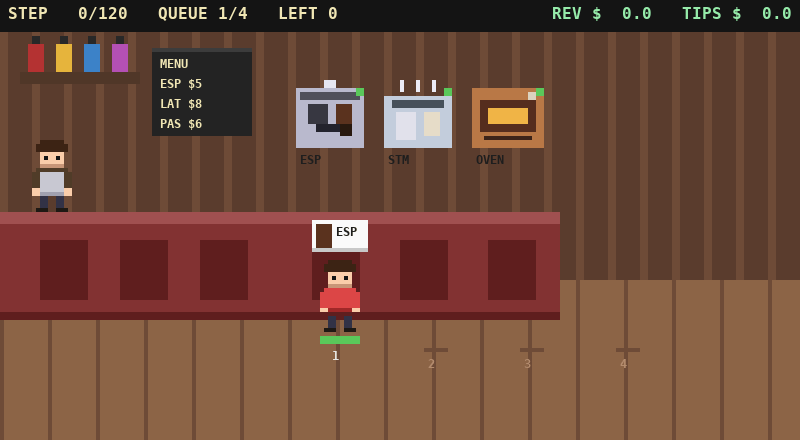

In [7]:
from IPython.display import Image as DisplayImage

DisplayImage(filename=GIF_PATH)